# **Age Estimation Project**

## **Import**

In [10]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 

import sklearn
from sklearn.model_selection import train_test_split

import torch 
import torchmetrics as tm
import torch.nn as nn
from torch.utils.data import Dataset , DataLoader , random_split
from torch import optim

import torchvision
from torchvision import transforms as T
from torchvision import models as models

from tqdm import tqdm

import cv2 as cv
import PIL
from PIL import Image

from ultralytics import YOLO
import os, hashlib , random

### Check versions of libraries and CUDA 

In [22]:
print(f"CUDA version: {torch.version.cuda}") if torch.cuda.is_available else print("Pytorch is using CPU")

CUDA version: 12.6


In [23]:
for lib in [np, pd, cv, PIL, sklearn, torch, torchvision, tm]:
  print(lib.__name__, '-->', lib.__version__)

numpy --> 1.26.4
pandas --> 2.2.2
cv2 --> 4.13.0
PIL --> 10.4.0
sklearn --> 1.3.0
torch --> 2.10.0+cu126
torchvision --> 0.25.0+cu126
torchmetrics --> 1.7.4


## **Utils**

In [2]:
class AverageMeter(object):
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

In [3]:
def num_trainable_params(model):
  nums = sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6
  return nums

In [4]:
def iter_images(root):
    IMG_EXTS = (".jpg", ".jpeg", ".png")
    for r, _, files in os.walk(root):
        for f in files:
            if f.lower().endswith(IMG_EXTS):
                yield os.path.join(r, f)

In [5]:
def uniq_name(path):
    h = hashlib.md5(path.encode("utf-8")).hexdigest()[:10]
    return f"{h}_{os.path.basename(path)}"

In [6]:
def expand_box(x1, y1, x2, y2, w, h, margin=0.2):
    bw, bh = x2 - x1, y2 - y1
    dx, dy = int(bw * margin / 2), int(bh * margin / 2)
    x1 = max(0, x1 - dx); y1 = max(0, y1 - dy)
    x2 = min(w, x2 + dx); y2 = min(h, y2 + dy)
    return x1, y1, x2, y2

## **Dataset**

### Recognize faces and crop   

#### Train datasets

In [ ]:
datasets = {
    "utkface": r"UTKFace",
    "wiki":    r"wiki_crop",
    "imdb":    r"imdb_crop",
}
output_root = r"cropped_faces"
MARGIN = 0.2
IMG_EXTS = (".jpg", ".jpeg", ".png")


model = YOLO(r"yolov8n-face.pt")  

for name, src in datasets.items():
    out_dir = os.path.join(output_root, name)
    os.makedirs(out_dir, exist_ok=True)

    total = saved = no_face = 0

    for p in tqdm(iter_images(src), desc=f"Cropping {name}"):
        total += 1
        img = cv.imread(p)
        if img is None:
            continue
        h, w = img.shape[:2]

        
        results = model(img , device=0 , verbose=False)
        boxes = results[0].boxes

        if boxes is None or len(boxes) == 0:
            no_face += 1
            continue

        
        b = max(boxes, key=lambda b: float((b.xyxy[0][2]-b.xyxy[0][0])*(b.xyxy[0][3]-b.xyxy[0][1])))
        x1, y1, x2, y2 = map(int, b.xyxy[0].tolist())

        x1, y1, x2, y2 = expand_box(x1, y1, x2, y2, w, h, margin=MARGIN)
        crop = img[y1:y2, x1:x2]
        if crop.size == 0:
            no_face += 1
            continue

        cv.imwrite(os.path.join(out_dir, uniq_name(p)), crop)
        saved += 1

    print(f"{name} ✅ total={total} | saved={saved} | no_face={no_face}")

print("All datasets processed successfully!")

Cropping utkface: 23692it [18:06, 21.80it/s]


utkface ✅ total=23692 | saved=23303 | no_face=389


Cropping wiki: 62328it [39:42, 26.16it/s]


wiki ✅ total=62328 | saved=51301 | no_face=11027


Cropping imdb: 460723it [5:55:05, 21.62it/s]

imdb ✅ total=460723 | saved=454905 | no_face=5818
All datasets processed successfully!


#### Test dataset

In [31]:
datasets = {
    "morph_2_test": r"C:/Users/bfarz/Neuron Network/Dataset/Images/Test",
    "morph_2_train":    r"C:/Users/bfarz/Neuron Network/Dataset/Images/Train",
    "morph_2_valid":    r"C:/Users/bfarz/Neuron Network/Dataset/Images/Validation",
}

output_root = r"morph_2_cropped_faces"
MARGIN = 0.2
IMG_EXTS = (".jpg", ".jpeg", ".png")


os.makedirs(output_root, exist_ok=True)

model = YOLO(r"yolov8n-face.pt")

total_all = saved_all = no_face_all = 0

for name, src in datasets.items():
    

    total = saved = no_face = 0

    for p in tqdm(iter_images(src), desc=f"Cropping {name}"):
        total += 1
        total_all += 1
        img = cv.imread(p)
        if img is None:
            continue
        h, w = img.shape[:2]

        
        results = model(img , device=0 , verbose=False)
        boxes = results[0].boxes

        if boxes is None or len(boxes) == 0:
            no_face += 1
            no_face_all += 1
            continue

        
        b = max(boxes, key=lambda b: float((b.xyxy[0][2]-b.xyxy[0][0])*(b.xyxy[0][3]-b.xyxy[0][1])))
        x1, y1, x2, y2 = map(int, b.xyxy[0].tolist())

        x1, y1, x2, y2 = expand_box(x1, y1, x2, y2, w, h, margin=MARGIN)
        crop = img[y1:y2, x1:x2]
        if crop.size == 0:
            no_face += 1
            no_face_all += 1
            continue
        
        save_path = os.path.join(output_root, uniq_name(p))
        cv.imwrite(save_path, crop)
        saved += 1
        saved_all += 1
        
    print(f"{name} ✅ total={total} | saved={saved} | no_face={no_face}")

print(f"ALL DATASETS DONE : total={total_all} | saved={saved_all} | no_face={no_face_all}")

Cropping morph_2_test: 5002it [02:41, 30.90it/s]


morph_2_test ✅ total=5002 | saved=5002 | no_face=0


Cropping morph_2_train: 40012it [18:37, 35.80it/s]


morph_2_train ✅ total=40012 | saved=40009 | no_face=3


Cropping morph_2_valid: 5001it [02:28, 33.73it/s]

morph_2_valid ✅ total=5001 | saved=5001 | no_face=0
ALL DATASETS DONE : total=50015 | saved=50012 | no_face=3


### **EDA**

#### UTKface

In [73]:

dataset_folder = "cropped_faces/utkface"
img_list = os.listdir(dataset_folder)

img_name_ls = []
age_ls = []
ethnicity_ls = []
gender_ls = []

removed_age = 0
removed_low_quality = 0
removed_blurry = 0
removed_invalid = 0

MIN_WIDTH = 100
MIN_HEIGHT = 100
MIN_PIXELS = 100 * 100
BLUR_THRESHOLD = 100

ethnicity_map = ['White', 'Black', 'Asian', 'Indian', 'Others']



for file in tqdm(img_list):
    try:
        if not file.endswith('.jpg'):
            continue

        img_path = os.path.join(dataset_folder, file)

        
        img = Image.open(img_path)
        width, height = img.size

        if width < MIN_WIDTH or height < MIN_HEIGHT or (width * height) < MIN_PIXELS:
            removed_low_quality += 1
            continue


        parts = file.split('_')

        if len(parts) < 5:
            removed_invalid += 1
            continue

        
        age = int(parts[1])
        gender = 'Male' if int(parts[2]) == 0 else 'Female'
        ethnicity = ethnicity_map[int(parts[3])]

        if age > 80 or age < 0:
            removed_age += 1
            continue

        img_name_ls.append(file)
        age_ls.append(age)
        ethnicity_ls.append(ethnicity)
        gender_ls.append(gender)

    except Exception:
        removed_invalid += 1
        continue


data = {
    'img_name': img_name_ls,
    'age': age_ls,
    'ethnicity': ethnicity_ls,
    'gender': gender_ls
}

utkface_df = pd.DataFrame(data)

os.makedirs('data', exist_ok=True)
csv_filename = 'data/utkface_dataset.csv'
utkface_df.to_csv(csv_filename, index=False)

print(f"CSV file '{csv_filename}' created successfully.")
print("-------------")
print(f"Total images: {len(img_list)}")
print(f"Removed (age filter): {removed_age}")
print(f"Removed (low quality): {removed_low_quality}")
print(f"Removed (invalid): {removed_invalid}")
print(f"Kept images: {len(img_name_ls)}")

100%|██████████| 23305/23305 [00:23<00:00, 1008.20it/s]

CSV file 'data/utkface_dataset.csv' created successfully.
-------------
Total images: 23305
Removed (age filter): 533
Removed (low quality): 4
Removed (invalid): 5
Kept images: 22763


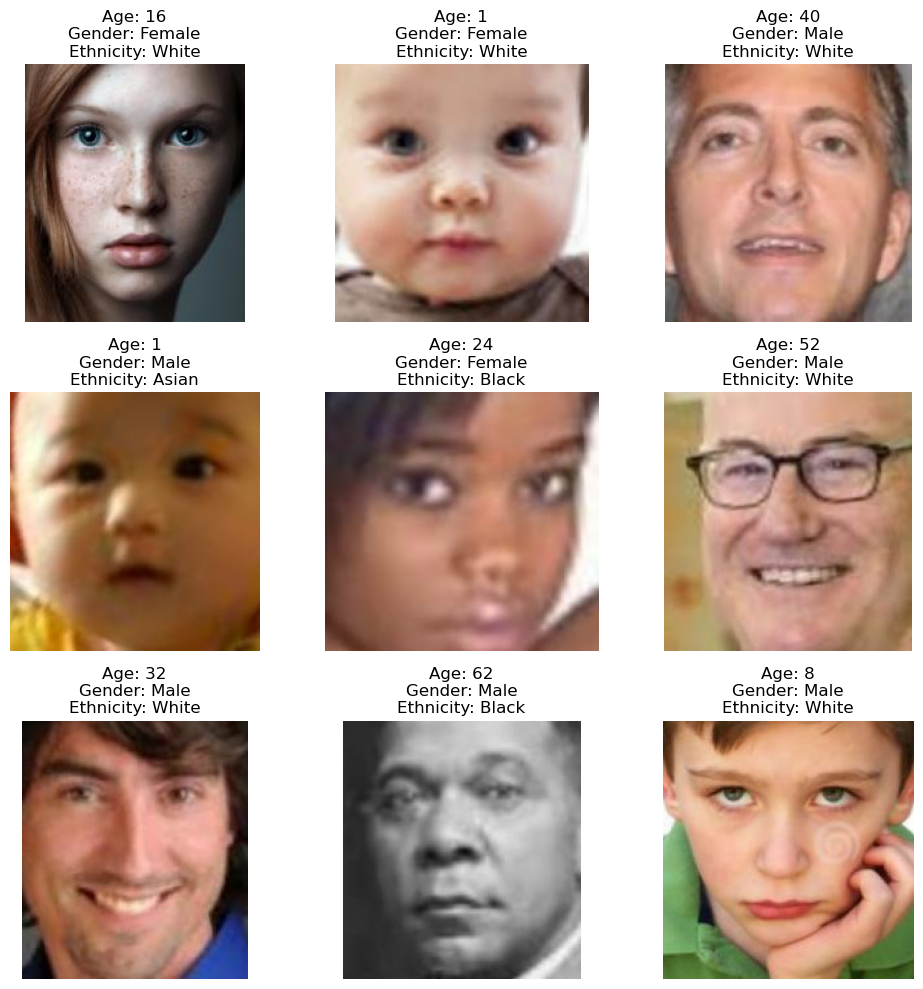

In [75]:
utkface_df = pd.read_csv('data/utkface_dataset.csv')
dataset_folder = "cropped_faces/utkface"
def show_random_samples(num_samples=10):

    plt.figure(figsize=(10, 10))
    for idx in range(1 , num_samples):
        a = random.randint(0 , len(utkface_df))
        age= utkface_df["age"][a]
        image_file = utkface_df["img_name"][a]
        ethnicity = utkface_df["ethnicity"][a]
        gender = utkface_df["gender"][a]
        image_path = os.path.join(dataset_folder, image_file)
        
        image = Image.open(image_path)

          

        plt.subplot(3, 3, idx)
        plt.imshow(image)
        plt.title(f"Age: {age}\nGender: {gender}\nEthnicity: {ethnicity}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
    

show_random_samples()


In [76]:
utkface_df.describe()

,age
count,22763.000000
mean,31.942319
std,18.241352
min,1.000000
25%,23.000000
50%,29.000000
75%,42.000000
max,80.000000


(array([       2873,        1171,        2800,        6641,        3248,        1535,        1951,        1157,         840,         547]),
 array([          1,         8.9,        16.8,        24.7,        32.6,        40.5,        48.4,        56.3,        64.2,        72.1,          80]),
 <BarContainer object of 10 artists>)

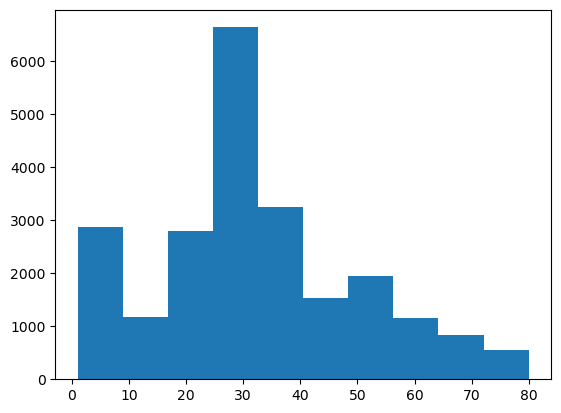

In [ ]:
plt.hist(utkface_df["age"]);

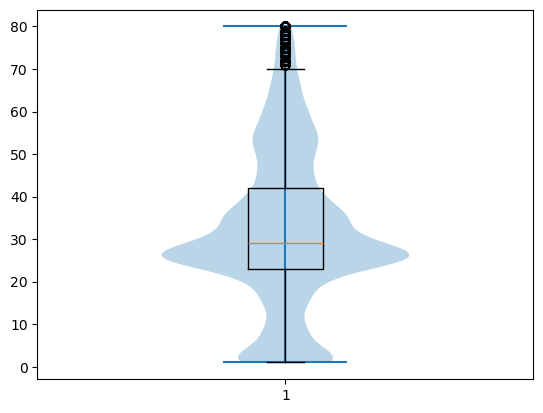

In [78]:
plt.violinplot(utkface_df["age"])
plt.boxplot(utkface_df["age"]);

#### WIKI

In [87]:

dataset_folder = 'cropped_faces/wiki'
img_list = os.listdir(dataset_folder)


img_name_ls = []
age_ls = []


removed_age = 0
removed_low_quality = 0



MIN_WIDTH = 100
MIN_HEIGHT = 100
MIN_PIXELS = 100 * 100





for image_file in tqdm(img_list):
    try:
        img_path = os.path.join(dataset_folder, image_file)

        img = Image.open(img_path)
        width, height = img.size

        
        if width < MIN_WIDTH or height < MIN_HEIGHT or (width * height) < MIN_PIXELS:
            removed_low_quality += 1
            continue

        
        a = image_file.split("_")
        bday = a[2].split("-")[0]
        cday = a[3].split(".")[0]
        age = int(cday) - int(bday)

        
        if age > 80 or age < 1:
            removed_age += 1
            continue

        
        img_name_ls.append(image_file)
        age_ls.append(age)

    except Exception:
        continue


data = {
    'img_name': img_name_ls,
    'age': age_ls,
}

wiki_df = pd.DataFrame(data)


csv_filename = 'data/wiki_dataset.csv'
os.makedirs('data', exist_ok=True)
wiki_df.to_csv(csv_filename, index=False)



print(f"CSV file '{csv_filename}' created successfully.")
print("-------------")
print(f"Total images: {len(img_list)}")
print(f"Removed (age filter): {removed_age}")
print(f"Removed (low quality): {removed_low_quality}")
print(f"Kept images: {len(img_name_ls)}")

100%|██████████| 51301/51301 [00:54<00:00, 934.10it/s] 

CSV file 'data/wiki_dataset.csv' created successfully.
-------------
Total images: 51301
Removed (age filter): 666
Removed (low quality): 23256
Kept images: 27379


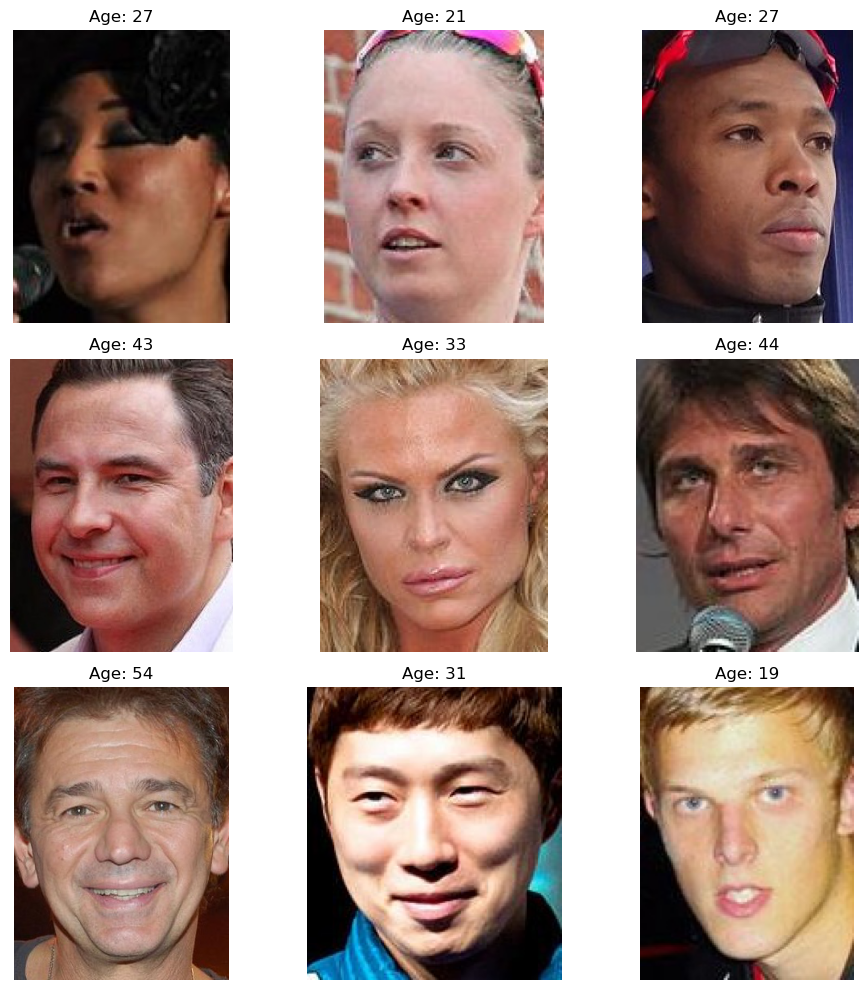

In [91]:
wiki_df = pd.read_csv('data/wiki_dataset.csv')
dataset_folder = 'cropped_faces/wiki'
def show_random_samples(num_samples=10):

    plt.figure(figsize=(10, 10))
    for idx in range(1 , num_samples):
        a = random.randint(0 , len(wiki_df))
        age= wiki_df["age"][a]
        image_file = wiki_df["img_name"][a]
        
        image_path = os.path.join(dataset_folder, image_file)
        
        image = Image.open(image_path)

          

        plt.subplot(3, 3, idx)
        plt.imshow(image)
        plt.title(f"Age: {age}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
    

show_random_samples()


In [89]:
wiki_df.describe()

,age
count,27379.000000
mean,38.981774
std,15.579661
min,1.000000
25%,26.000000
50%,35.000000
75%,50.000000
max,80.000000


(array([         23,         276,        4715,        7170,        4318,        3497,        2927,        2138,        1461,         854]),
 array([          1,         8.9,        16.8,        24.7,        32.6,        40.5,        48.4,        56.3,        64.2,        72.1,          80]),
 <BarContainer object of 10 artists>)

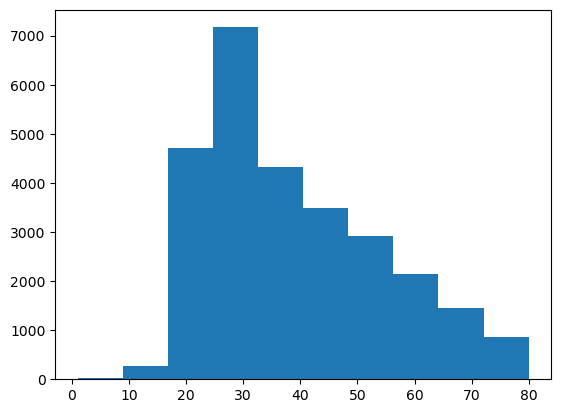

In [ ]:
plt.hist(wiki_df["age"]);

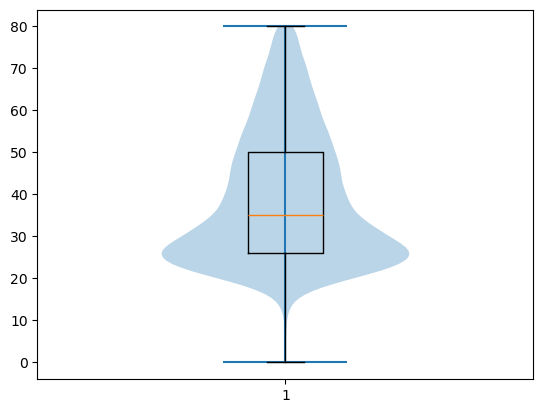

In [85]:
plt.violinplot(wiki_df["age"])
plt.boxplot(wiki_df["age"]);

#### IMDB

In [92]:

dataset_folder = 'cropped_faces/imdb'
img_list = os.listdir(dataset_folder)


img_name_ls = []
age_ls = []


removed_age = 0
removed_low_quality = 0



MIN_WIDTH = 100
MIN_HEIGHT = 100
MIN_PIXELS = 100 * 100





for image_file in tqdm(img_list):
    try:
        img_path = os.path.join(dataset_folder, image_file)

        img = Image.open(img_path)
        width, height = img.size

        
        if width < MIN_WIDTH or height < MIN_HEIGHT or (width * height) < MIN_PIXELS:
            removed_low_quality += 1
            continue

        
        a = image_file.split("_")
        bday = a[4].split("-")[0]
        cday = a[5].split(".")[0]
        age = int(cday) - int(bday)

        
        if age > 80 or age < 1:
            removed_age += 1
            continue

        
        img_name_ls.append(image_file)
        age_ls.append(age)

    except Exception:
        continue


data = {
    'img_name': img_name_ls,
    'age': age_ls,
}

imdb_df = pd.DataFrame(data)


csv_filename = 'data/imdb_dataset.csv'
os.makedirs('data', exist_ok=True)
imdb_df.to_csv(csv_filename, index=False)



print(f"CSV file '{csv_filename}' created successfully.")
print("-------------")
print(f"Total images: {len(img_list)}")
print(f"Removed (age filter): {removed_age}")
print(f"Removed (low quality): {removed_low_quality}")
print(f"Kept images: {len(img_name_ls)}")

100%|██████████| 454905/454905 [08:28<00:00, 895.34it/s] 


CSV file 'data/imdb_dataset.csv' created successfully.
-------------
Total images: 454905
Removed (age filter): 1223
Removed (low quality): 222578
Kept images: 231104


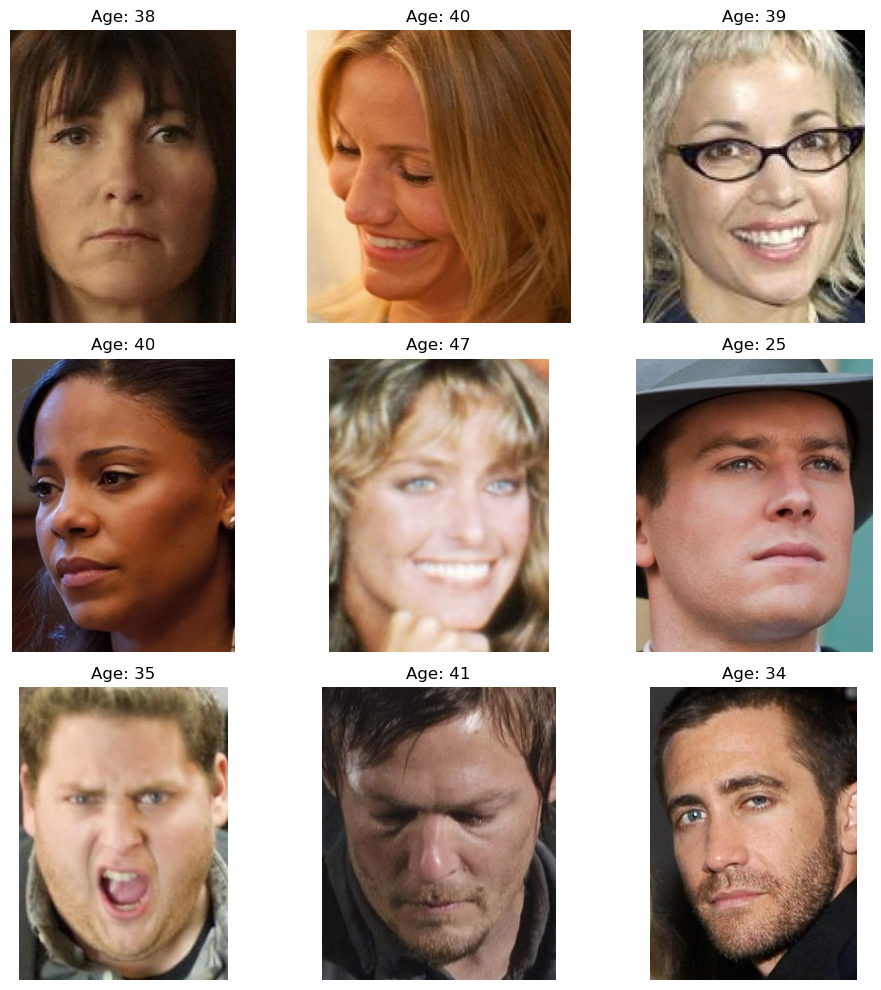

In [118]:
imdb_df = pd.read_csv('data/imdb_dataset.csv')
dataset_folder = 'cropped_faces/imdb'
def show_random_samples(num_samples=10):

    plt.figure(figsize=(10, 10))
    for idx in range(1 , num_samples):
        a = random.randint(0 , len(imdb_df))
        age= imdb_df["age"][a]
        image_file = imdb_df["img_name"][a]
        
        image_path = os.path.join(dataset_folder, image_file)
        
        image = Image.open(image_path)

          

        plt.subplot(3, 3, idx)
        plt.imshow(image)
        plt.title(f"Age: {age}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
    

show_random_samples()


In [122]:
imdb_df.describe()

,age
count,231104.000000
mean,37.444605
std,13.072530
min,1.000000
25%,28.000000
50%,36.000000
75%,45.000000
max,80.000000


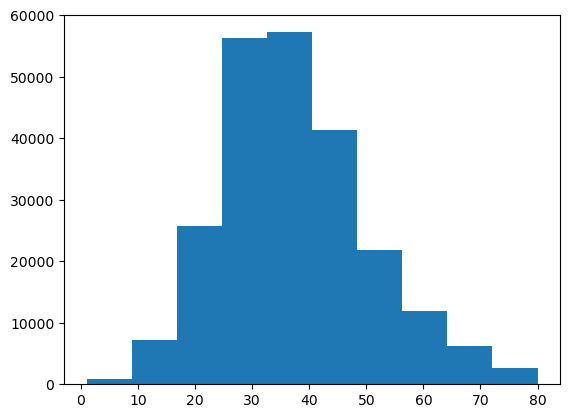

In [119]:
plt.hist(imdb_df["age"]);

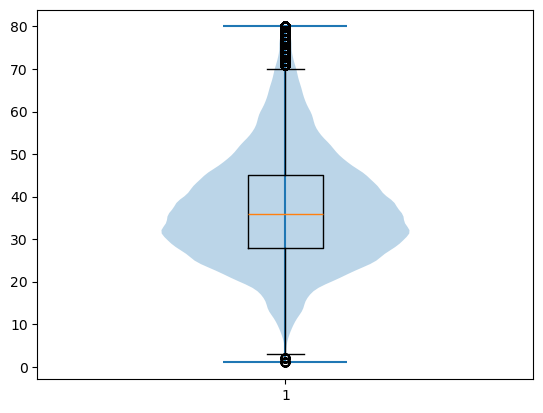

In [123]:
plt.violinplot(imdb_df["age"])
plt.boxplot(imdb_df["age"]);

### Open images from datasets